# Gradient Boosting (2/2) — Gradient Boosting in scikit-learn

**Idea:** in notebook 1 we built gradient boosting by hand. Now we use scikit-learn's ready-made classes on bigger data
and learn how to **tune** them: number of trees, learning rate, tree size, subsampling and early stopping.

**In this notebook**
1. Regression data: `make_friedman1`
2. A first `GradientBoostingRegressor` (vs a single tree)
3. Error vs number of trees with `staged_predict`
4. Learning rate × number of trees
5. Tree size: `max_depth`
6. Stochastic gradient boosting: `subsample`
7. Early stopping: `n_iter_no_change`
8. A small `GridSearchCV`
9. Feature importance
10. Classification: `GradientBoostingClassifier` on breast cancer data
11. Gradient boosting vs Random Forest

> 📖 Theory: [`theory.md`](theory.md) §5–§12 · ✍️ = core code to learn · 🎨 = visualization only (collapsed)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_friedman1, load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (GradientBoostingRegressor, GradientBoostingClassifier,
                              RandomForestRegressor, RandomForestClassifier,
                              HistGradientBoostingRegressor, HistGradientBoostingClassifier)
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score, log_loss

plt.rcParams.update({'figure.dpi': 100, 'axes.spines.top': False, 'axes.spines.right': False})
pd.set_option('display.float_format', '{:.3f}'.format)

## 1. Regression data: `make_friedman1`

A classic synthetic benchmark with **10 features** $x_0 \dots x_9$ (each uniform in [0, 1]) and

$$y = 10\sin(\pi x_0 x_1) + 20(x_2 - 0.5)^2 + 10x_3 + 5x_4 + \text{noise}$$

Only $x_0 \dots x_4$ matter; **$x_5 \dots x_9$ are pure noise**. That is handy: later we can check whether the
feature importances find the right features. It mixes an interaction ($x_0 x_1$), a curve and straight lines.

> ✍️ **Core code: learn this.** Create the data and split it.

In [2]:
X, y = make_friedman1(n_samples=1000, n_features=10, noise=1.0, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print('train:', X_train.shape, '| test:', X_test.shape)
pd.DataFrame(X_train, columns=[f'x{i}' for i in range(10)]).assign(y=y_train).head()

train: (750, 10) | test: (250, 10)


,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,y
0,0.803,0.005,0.333,0.398,0.537,0.920,0.346,0.347,0.738,0.452,7.267
1,0.328,0.908,0.097,0.606,0.451,0.938,0.123,0.212,0.030,0.434,20.155
2,0.150,0.504,0.802,0.442,0.491,0.849,0.706,0.490,0.258,0.885,11.194
3,0.462,0.390,0.864,0.929,0.303,0.864,0.782,0.931,0.246,0.577,17.663
4,0.832,0.806,0.224,0.226,0.817,0.930,0.095,0.450,0.337,0.871,16.278


## 2. A first `GradientBoostingRegressor`

Defaults: `n_estimators=100`, `learning_rate=0.1`, `max_depth=3`, loss = squared error. We compare it with one
fully grown decision tree.

> ✍️ **Core code: learn this.** Fit, predict, score: the usual three lines.

In [3]:
tree = DecisionTreeRegressor(random_state=42).fit(X_train, y_train)
gbr  = GradientBoostingRegressor(random_state=42).fit(X_train, y_train)

def scores(model):
    p = model.predict(X_test)
    return {'test R²': r2_score(y_test, p), 'test RMSE': mean_squared_error(y_test, p) ** 0.5}

pd.DataFrame({'Single decision tree': scores(tree), 'Gradient boosting (defaults)': scores(gbr)}).T

,test R²,test RMSE
Single decision tree,0.599,2.954
Gradient boosting (defaults),0.902,1.463


Gradient boosting explains about **90%** of the variance on unseen data (test R² 0.902) while one deep tree manages
only 0.599. The RMSE (typical error, in the units of y) is halved: 1.46 vs 2.95. Many small trees that correct each other
beat one big tree by a wide margin.

## 3. Error vs number of trees with `staged_predict`

`staged_predict(X)` gives the prediction after 1 tree, after 2 trees, …, after all trees, **without retraining**.
Perfect for drawing the learning curve of one boosted model.

> ✍️ **Core code: learn this.** `staged_predict` = predictions after each stage (tree).

In [4]:
gb_big = GradientBoostingRegressor(n_estimators=1000, learning_rate=0.1, random_state=42).fit(X_train, y_train)

train_mse = [mean_squared_error(y_train, p) for p in gb_big.staged_predict(X_train)]
test_mse  = [mean_squared_error(y_test,  p) for p in gb_big.staged_predict(X_test)]
best = int(np.argmin(test_mse)) + 1
print(f'best number of trees on the test set: {best} (test MSE {min(test_mse):.3f})')
print(f'test MSE after 100 trees: {test_mse[99]:.3f} | after 1000 trees: {test_mse[-1]:.3f}')
print(f'train MSE after 1000 trees: {train_mse[-1]:.4f}')

best number of trees on the test set: 243 (test MSE 1.927)
test MSE after 100 trees: 2.141 | after 1000 trees: 1.956
train MSE after 1000 trees: 0.0097


> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

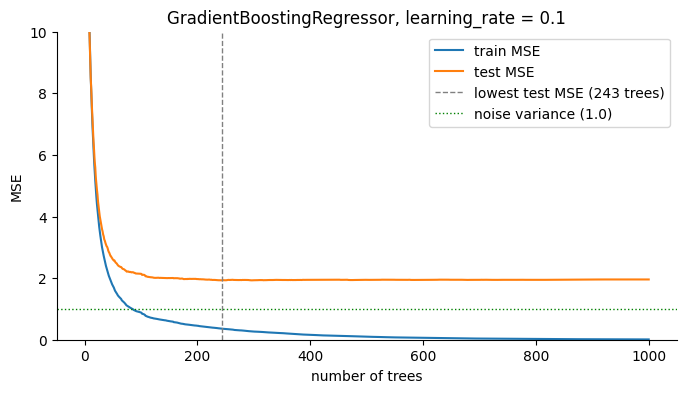

In [5]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, 1001), train_mse, label='train MSE')
plt.plot(range(1, 1001), test_mse, label='test MSE')
plt.axvline(best, color='gray', ls='--', lw=1, label=f'lowest test MSE ({best} trees)')
plt.axhline(1.0, color='green', ls=':', lw=1, label='noise variance (1.0)')
plt.ylim(0, 10); plt.xlabel('number of trees'); plt.ylabel('MSE')
plt.title('GradientBoostingRegressor, learning_rate = 0.1')
plt.legend(); plt.show()

- The **train** MSE keeps falling, down to 0.0097 after 1000 trees: far below the noise variance (1.0), so the model is
  memorising noise.
- The **test** MSE drops fast during the first ~100 trees, is lowest at 243 trees (1.927), and then rises only a tiny bit
  (1.956 at 1000 trees). With `learning_rate=0.1` and small trees, overfitting here is **slow and mild**, but the
  extra 750 trees bought nothing.
- Choosing the number of trees by looking at the **test** set (as we did here for the picture) is cheating in real life:
  use cross-validation or early stopping (section 7).

## 4. Learning rate × number of trees

The learning rate and the number of trees work **together**: half the learning rate ≈ needs about twice the trees.
We train 1000 trees for several learning rates and track the test error after each tree.

In [6]:
rates = [0.01, 0.05, 0.1, 0.3, 1.0]
curves, rows = {}, []
for lr in rates:
    m = GradientBoostingRegressor(n_estimators=1000, learning_rate=lr, random_state=42).fit(X_train, y_train)
    te = np.array([mean_squared_error(y_test, p) for p in m.staged_predict(X_test)])
    tr = np.array([mean_squared_error(y_train, p) for p in m.staged_predict(X_train)])
    curves[lr] = (tr, te)
    rows.append({'learning_rate': lr, 'best #trees': te.argmin() + 1, 'best test MSE': te.min(),
                 'test MSE @100 trees': te[99], 'test MSE @1000 trees': te[-1]})
lr_table = pd.DataFrame(rows).set_index('learning_rate')
lr_table

,best #trees,best test MSE,test MSE @100 trees,test MSE @1000 trees
learning_rate,,,,
0.010,998,2.078,9.345,2.079
0.050,963,1.833,2.579,1.837
0.100,243,1.927,2.141,1.956
0.300,84,1.885,1.902,1.999
1.000,10,3.609,4.273,4.292


> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

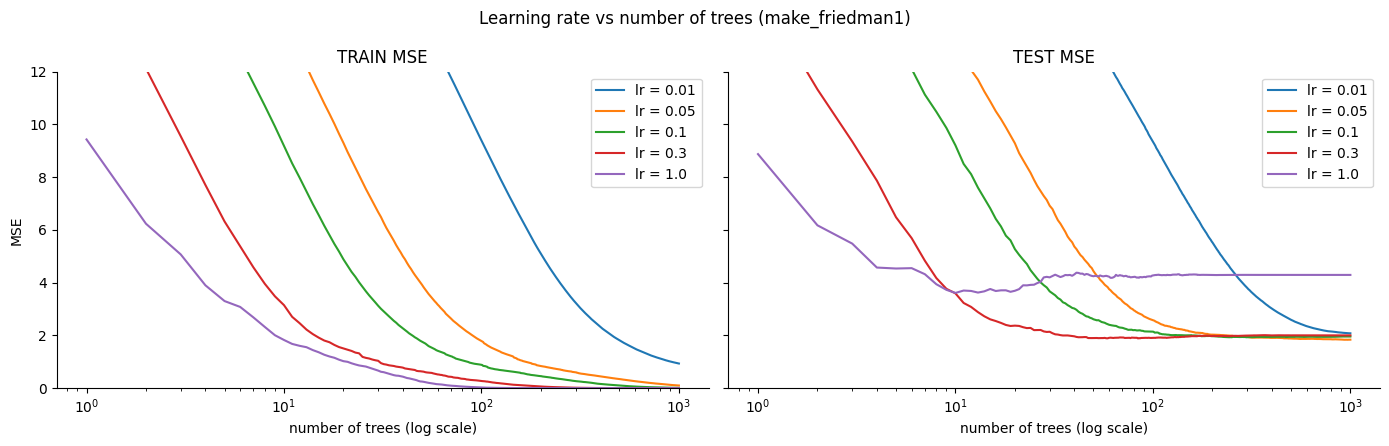

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
for lr in rates:
    tr, te = curves[lr]
    axes[0].plot(range(1, 1001), tr, label=f'lr = {lr}')
    axes[1].plot(range(1, 1001), te, label=f'lr = {lr}')
for ax, t in zip(axes, ['TRAIN MSE', 'TEST MSE']):
    ax.set_xscale('log'); ax.set_ylim(0, 12); ax.set_xlabel('number of trees (log scale)'); ax.set_title(t); ax.legend()
axes[0].set_ylabel('MSE')
plt.suptitle('Learning rate vs number of trees (make_friedman1)')
plt.tight_layout(); plt.show()

What the table and plot show:
- **lr = 1.0:** learns fastest but is the worst by far (best test MSE 3.61 after just 10 trees, then 4.29 at 1000 trees).
  Each tree over-corrects.
- **lr = 0.01:** far too slow: after 100 trees the test MSE is still 9.35, and even after 1000 trees (2.08) it is still
  improving. It needs many more trees.
- **lr = 0.05, 0.1, 0.3** all end up close together (best test MSE 1.83–1.93). The smaller the rate, the more trees it
  takes to get there: about 84 trees at 0.3, 243 at 0.1, 963 at 0.05.
- Rule of thumb: **smaller learning rate + more trees** is usually as good or slightly better, but slower to train.

## 5. Tree size: `max_depth`

Boosting usually uses **small** trees (depth 2–5). Depth 1 (a stump) can only use one feature per tree, so it cannot
model interactions like $x_0 x_1$ well. Deep trees overfit quickly. We keep 300 trees and `learning_rate=0.1`.

In [8]:
rows = []
for d in [1, 2, 3, 5, 8]:
    m = GradientBoostingRegressor(n_estimators=300, learning_rate=0.1, max_depth=d, random_state=42).fit(X_train, y_train)
    rows.append({'max_depth': d, 'train R²': r2_score(y_train, m.predict(X_train)), 'test R²': r2_score(y_test, m.predict(X_test))})
depth_table = pd.DataFrame(rows).set_index('max_depth')
depth_table

,train R²,test R²
max_depth,,
1,0.897,0.875
2,0.968,0.910
3,0.989,0.911
5,1.000,0.906
8,1.000,0.833


> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

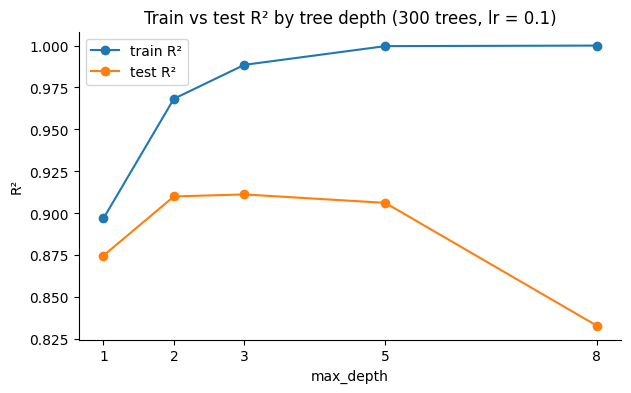

In [9]:
ax = depth_table.plot(marker='o', figsize=(7, 4))
ax.set_title('Train vs test R² by tree depth (300 trees, lr = 0.1)'); ax.set_ylabel('R²')
ax.set_xticks(depth_table.index); plt.show()

- **Depth 1 (stumps)** underfits (test R² 0.875): one feature per tree cannot capture the $x_0 x_1$ interaction.
- **Depth 2–3** is best here (test R² 0.910–0.911).
- **Depth 5** already fits the training data perfectly (train R² 1.000) and is slightly worse on test (0.906);
  **depth 8** clearly overfits (test R² 0.833).

In gradient boosting, **shallow trees are the norm** (the default is `max_depth=3`).

## 6. Stochastic gradient boosting: `subsample`

With `subsample < 1`, each tree is trained on a **random fraction of the rows** (drawn without replacement).
This adds randomness (like bagging), which can reduce overfitting, and makes each tree faster to train.

> ✍️ **Core code: learn this.** `subsample=0.8` → every tree sees a random 80% of the training rows.

In [10]:
rows = []
for ss in [1.0, 0.8, 0.5]:
    m = GradientBoostingRegressor(n_estimators=300, learning_rate=0.1, subsample=ss, random_state=42).fit(X_train, y_train)
    rows.append({'subsample': ss, 'test R²': r2_score(y_test, m.predict(X_test))})
pd.DataFrame(rows).set_index('subsample')

,test R²
subsample,
1.000,0.911
0.800,0.918
0.500,0.920


Here, training each tree on a random 80% or 50% of the rows gave a slightly **better** test R² (0.918 and 0.920 vs 0.911).
The gain is small and comes from one train/test split, so treat `subsample` as a knob worth trying (typical values 0.5–0.8),
not a guaranteed win.

## 7. Early stopping: `n_iter_no_change`

Instead of guessing the number of trees, let the model decide:
- `validation_fraction=0.1` → keep 10% of the **training** data aside as a validation set;
- `n_iter_no_change=10` → stop when the validation score has not improved for 10 trees in a row;
- `n_estimators` becomes just an **upper limit**. The number actually used is stored in `n_estimators_`.

Note: the test set is never used for this decision.

> ✍️ **Core code: learn this.** Early stopping: a big `n_estimators` limit plus `n_iter_no_change`.

In [11]:
gb_es = GradientBoostingRegressor(n_estimators=5000, learning_rate=0.1,
                                  validation_fraction=0.1, n_iter_no_change=10,
                                  random_state=42).fit(X_train, y_train)
print('trees actually built (n_estimators_):', gb_es.n_estimators_)
print(f"test R² with early stopping       : {r2_score(y_test, gb_es.predict(X_test)):.3f}")
print(f"test R² with 100 trees (default)  : {r2_score(y_test, gbr.predict(X_test)):.3f}")

trees actually built (n_estimators_): 178
test R² with early stopping       : 0.915
test R² with 100 trees (default)  : 0.902


Early stopping used only **178** of the allowed 5000 trees and scored a test R² of 0.915, a bit better than the
default 100 trees (0.902), without us choosing the number of trees by hand. It also saves a lot of training time.

## 8. A small `GridSearchCV`

Let cross-validation (on the training set only) choose the learning rate, number of trees and depth:
3 × 2 × 3 = 18 combinations × 5 folds = 90 fits.

> ✍️ **Core code: learn this.** Tune the three most important knobs together.

In [12]:
param_grid = {
    'learning_rate': [0.05, 0.1, 0.2],
    'n_estimators':  [100, 300],
    'max_depth':     [2, 3, 4],
}
grid = GridSearchCV(GradientBoostingRegressor(random_state=42), param_grid, cv=5, scoring='r2', n_jobs=-1)
grid.fit(X_train, y_train)
print('best parameters:', grid.best_params_)
print(f'best CV R²     : {grid.best_score_:.3f}')
print(f'test R²        : {r2_score(y_test, grid.predict(X_test)):.3f}')

best parameters: {'learning_rate': 0.2, 'max_depth': 2, 'n_estimators': 300}
best CV R²     : 0.896
test R²        : 0.911


In [13]:
res = pd.DataFrame(grid.cv_results_)
res = res[['param_learning_rate', 'param_n_estimators', 'param_max_depth', 'mean_test_score']]
res.sort_values('mean_test_score', ascending=False).head(6)

,param_learning_rate,param_n_estimators,param_max_depth,mean_test_score
13,0.200,300,2,0.896
7,0.100,300,2,0.892
9,0.100,300,3,0.891
15,0.200,300,3,0.890
14,0.200,100,3,0.888
3,0.050,300,3,0.884


- The winner is `learning_rate=0.2, max_depth=2, n_estimators=300` (CV R² 0.896, test R² 0.911).
- The top settings are all close (CV R² 0.884–0.896): gradient boosting is fairly robust once the knobs are in a sensible range.
- The best values sit at the **edge** of the grid (most trees, smallest depth), so a wider grid might do a little better.
  Grids are always a trade-off with compute: these 90 fits are the slowest cell in the notebook.

## 9. Feature importance

`feature_importances_` = how much each feature reduced the squared error, summed over all splits of all trees
(normalised to sum to 1). We know the truth here: only $x_0 \dots x_4$ are used to make $y$.

In [14]:
best_gb = grid.best_estimator_
imp = pd.Series(best_gb.feature_importances_, index=[f'x{i}' for i in range(10)])
imp.sort_values(ascending=False).to_frame('importance').T

,x3,x1,x0,x4,x2,x6,x9,x5,x7,x8
importance,0.333,0.241,0.209,0.105,0.090,0.005,0.005,0.004,0.004,0.004


> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

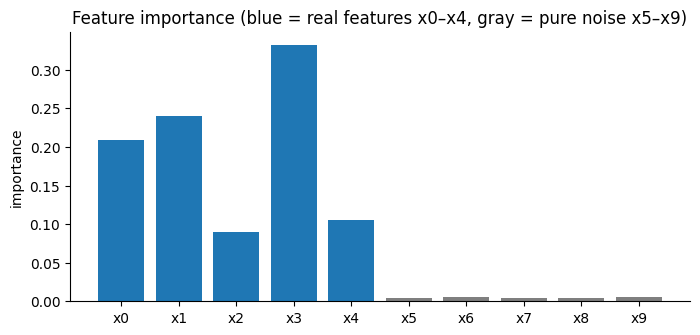

In [15]:
colors = ['tab:blue'] * 5 + ['tab:gray'] * 5
plt.figure(figsize=(8, 3.5))
plt.bar(imp.index, imp.values, color=colors)
plt.title('Feature importance (blue = real features x0–x4, gray = pure noise x5–x9)')
plt.ylabel('importance'); plt.show()

The model found the truth: the five real features $x_0 \dots x_4$ get almost all the importance, and the five noise
features get about 0.005 each. Ranking: $x_3$ (0.333), $x_1$ (0.241), $x_0$ (0.209), $x_4$ (0.105), $x_2$ (0.090).
$x_2$ is lowest among the real features because its term $20(x_2 - 0.5)^2$ only varies between 0 and 5, while
$10x_3$ varies between 0 and 10.

## 10. Classification: `GradientBoostingClassifier`

Breast cancer data (569 tumours, 30 numeric features, target 1 = benign, 0 = malignant).
For classification, gradient boosting does **not** add up class labels. It adds up **log-odds** scores:

$$F(x) = F_0 + \eta\,(h_1(x) + h_2(x) + \dots), \qquad P(\text{class } 1) = \text{sigmoid}(F(x)) = \frac{1}{1 + e^{-F(x)}}$$

Each tree is still a **regression** tree; it is fitted on the negative gradient of the log-loss, $y - p$
(actual label minus predicted probability).

> ✍️ **Core code: learn this.** Same API as the regressor.

In [16]:
Xc, yc = load_breast_cancer(return_X_y=True)
Xc_train, Xc_test, yc_train, yc_test = train_test_split(Xc, yc, test_size=0.25, random_state=42, stratify=yc)

gbc = GradientBoostingClassifier(random_state=42).fit(Xc_train, yc_train)
print(f'test accuracy: {accuracy_score(yc_test, gbc.predict(Xc_test)):.3f}')
print(f'test log-loss: {log_loss(yc_test, gbc.predict_proba(Xc_test)):.3f}')

test accuracy: 0.958
test log-loss: 0.125


**Check the log-odds story.** `decision_function` returns the raw score $F(x)$ (log-odds). Pushing it through the
sigmoid should give exactly `predict_proba`. The starting score $F_0$ is the log-odds of the class balance in the training set.

In [17]:
raw = gbc.decision_function(Xc_test[:5])
p_sigmoid = 1 / (1 + np.exp(-raw))
p_sklearn = gbc.predict_proba(Xc_test[:5])[:, 1]
print(pd.DataFrame({'log-odds F(x)': raw, 'sigmoid(F)': p_sigmoid, 'predict_proba[:,1]': p_sklearn}).round(4))
print('sigmoid(decision_function) == predict_proba :', np.allclose(p_sigmoid, p_sklearn))

p1 = yc_train.mean()
print(f"starting probability from gbc.init_ (class prior): {gbc.init_.predict_proba(Xc_test[:1])[0, 1]:.3f}")
print(f'F0 = log(p/(1-p)) with p = share of class 1 = {p1:.3f}  ->  {np.log(p1 / (1 - p1)):.4f}')

   log-odds F(x)  sigmoid(F)  predict_proba[:,1]
0          7.399       0.999               0.999
1         -7.705       0.001               0.001
2          1.732       0.850               0.850
3          4.774       0.992               0.992
4          3.618       0.974               0.974
sigmoid(decision_function) == predict_proba : True
starting probability from gbc.init_ (class prior): 0.627
F0 = log(p/(1-p)) with p = share of class 1 = 0.627  ->  0.5183


In [18]:
stages = range(1, gbc.n_estimators_ + 1)
tr_ll = [log_loss(yc_train, p) for p in gbc.staged_predict_proba(Xc_train)]
te_ll = [log_loss(yc_test,  p) for p in gbc.staged_predict_proba(Xc_test)]
te_acc = [accuracy_score(yc_test, p) for p in gbc.staged_predict(Xc_test)]
print(f'test accuracy after 10 / 50 / 100 trees: {te_acc[9]:.3f} / {te_acc[49]:.3f} / {te_acc[99]:.3f}')
print(f'lowest test log-loss {min(te_ll):.3f} at {int(np.argmin(te_ll)) + 1} trees')

test accuracy after 10 / 50 / 100 trees: 0.937 / 0.944 / 0.958
lowest test log-loss 0.118 at 63 trees


> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

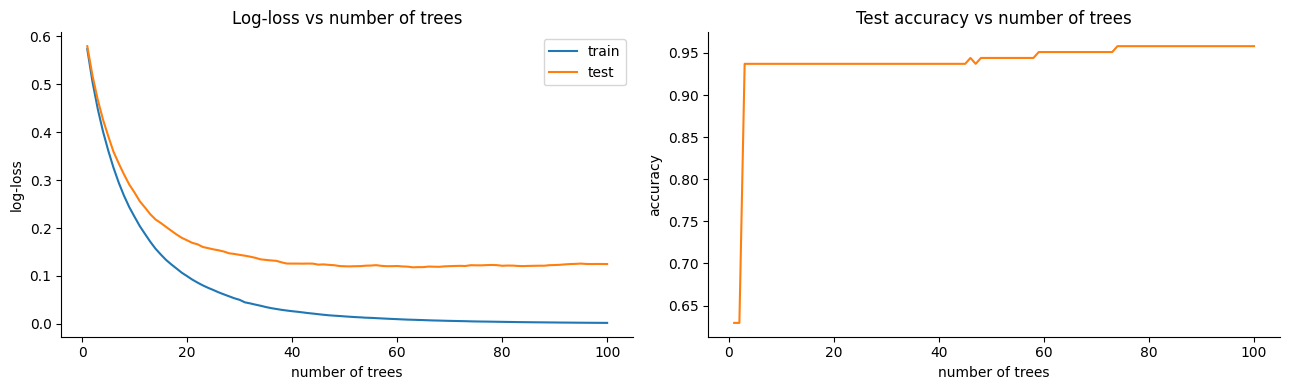

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(stages, tr_ll, label='train'); axes[0].plot(stages, te_ll, label='test')
axes[0].set_title('Log-loss vs number of trees'); axes[0].set_xlabel('number of trees'); axes[0].set_ylabel('log-loss'); axes[0].legend()
axes[1].plot(stages, te_acc, color='tab:orange')
axes[1].set_title('Test accuracy vs number of trees'); axes[1].set_xlabel('number of trees'); axes[1].set_ylabel('accuracy')
plt.tight_layout(); plt.show()

- `sigmoid(decision_function)` matches `predict_proba` exactly: the trees really add up **log-odds**.
- For the first 2 trees the test accuracy is only about 0.63: the scores have not moved far enough from the starting
  value, so every tumour is still predicted "benign" (the majority class). From tree 3 on it jumps to 0.937 and ends at
  0.958 after 100 trees.
- The test log-loss is lowest (0.118) at 63 trees and ends at 0.125: a very slight rise, a mild sign of overfitting,
  while the train log-loss keeps going down towards 0.

Early stopping works for classification too:

In [20]:
gbc_es = GradientBoostingClassifier(n_estimators=1000, learning_rate=0.1, n_iter_no_change=10,
                                    validation_fraction=0.1, random_state=42).fit(Xc_train, yc_train)
print('trees used with early stopping:', gbc_es.n_estimators_)
print(f'test accuracy with early stopping: {accuracy_score(yc_test, gbc_es.predict(Xc_test)):.3f}')

trees used with early stopping: 51
test accuracy with early stopping: 0.937


Honest result: here early stopping stopped at 51 trees and scored **lower** test accuracy (0.937 vs 0.958, i.e. 3 more
mistakes out of 143 test tumours). With a small dataset, the 10% validation set is only about 43 rows, so its score is
noisy and the stopping point is a bit random. Early stopping is most reliable on larger datasets.

## 11. Gradient boosting vs Random Forest

| | Random Forest | Gradient Boosting |
|---|---|---|
| Trees built | independently (in parallel) | one after another, each fixing the previous |
| Tree type | deep trees, averaged | small trees, added up |
| Mainly reduces | variance | bias (and variance via shrinkage) |
| Tuning needed | little | more (learning rate, trees, depth) |

We also add `HistGradientBoosting*`, scikit-learn's fast histogram-based gradient boosting (theory §11).

In [21]:
reg_models = {
    'Random Forest (300 trees)':      RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    'Gradient Boosting (defaults)':   GradientBoostingRegressor(random_state=42),
    'Gradient Boosting (grid-tuned on Friedman)': grid.best_estimator_,
    'HistGradientBoosting (defaults)': HistGradientBoostingRegressor(random_state=42),
}
clf_models = {
    'Random Forest (300 trees)':      RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    'Gradient Boosting (defaults)':   GradientBoostingClassifier(random_state=42),
    'Gradient Boosting (grid-tuned on Friedman)': None,
    'HistGradientBoosting (defaults)': HistGradientBoostingClassifier(random_state=42),
}
rows = []
for name in reg_models:
    r = reg_models[name].fit(X_train, y_train)
    row = {'model': name, 'Friedman test R²': r2_score(y_test, r.predict(X_test))}
    c = clf_models[name]
    row['Breast cancer test accuracy'] = accuracy_score(yc_test, c.fit(Xc_train, yc_train).predict(Xc_test)) if c is not None else np.nan
    rows.append(row)
pd.DataFrame(rows).set_index('model').style.format(precision=3, na_rep='—')

,Friedman test R²,Breast cancer test accuracy
model,,
Random Forest (300 trees),0.830,0.958
Gradient Boosting (defaults),0.902,0.958
Gradient Boosting (grid-tuned on Friedman),0.911,—
HistGradientBoosting (defaults),0.905,0.972


- **Regression (Friedman):** gradient boosting is clearly better than the random forest (test R² 0.902 default /
  0.911 tuned vs 0.830). The target is a smooth sum of effects, which boosting builds up piece by piece.
- **Classification (breast cancer):** random forest and default gradient boosting tie (0.958); `HistGradientBoostingClassifier`
  scored 0.972 (2 more correct tumours out of 143). Differences this small on 143 test rows are not strong evidence.
- Gradient boosting is often the strongest choice on tabular data, but it is **not automatically** better: always compare.

## Key takeaways

- `GradientBoostingRegressor` / `GradientBoostingClassifier` share one API: `n_estimators`, `learning_rate`, `max_depth`, `subsample`.
- `staged_predict` shows the error after each tree: training error always falls, test error flattens and can rise.
- **Learning rate and number of trees go together**: lr = 1.0 was worst; lr = 0.01 was too slow for 1000 trees; 0.05–0.3 were all good.
- Use **shallow trees** (depth 2–3 were best here; depth 8 overfitted).
- **Early stopping** (`n_iter_no_change`, `validation_fraction`) picks the number of trees for you (178 trees here), but on small data it can be noisy.
- Feature importances correctly found the 5 real Friedman features.
- For classification the trees add up **log-odds**; `predict_proba` = sigmoid of `decision_function`.
- Gradient boosting beat random forest clearly on Friedman regression; on breast cancer they tied.

## 🧠 Quick check

<details><summary>1. What does <code>staged_predict</code> give you, and why is it useful?</summary>
The predictions after 1, 2, …, n trees from one fitted model. It lets you plot error vs number of trees (and pick a good number) without retraining.</details>

<details><summary>2. You lower <code>learning_rate</code> from 0.1 to 0.01. What happens if you keep <code>n_estimators=100</code>?</summary>
The model underfits: each tree adds only 1% of its correction, so 100 trees are far too few. You need many more trees (here even 1000 trees at 0.01 were not quite enough).</details>

<details><summary>3. With <code>n_iter_no_change=10</code>, which data decides when to stop?</summary>
A validation set carved out of the training data (<code>validation_fraction</code>, 10% by default), never the test set. The number of trees used is in <code>n_estimators_</code>.</details>

<details><summary>4. For classification, what do the trees add up?</summary>
Log-odds scores. The final probability is sigmoid(F(x)); <code>decision_function</code> returns F(x) and <code>predict_proba</code> returns the sigmoid of it.</details>

➡️ **Next:** [`../07-xgboost/`](../07-xgboost/): XGBoost, a faster, regularised implementation of gradient boosting.